# NeuroBEM — noise & data-quality EDA

Noise = raw − low-pass(raw), ranked by SNR (lower = noisier). Helpers in `utils.py`. Each section is shown for the **wild** flight, then the **calm** flight.

In [18]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import utils as u

WILD = '2021-02-23-19-15-11'   # ellipse, ~19 m/s (aggressive)
CALM = '2021-02-23-10-43-02'   # slow lemniscate, vel=0.35 (calm)
wild = u.load_largest_segment(WILD)
calm = u.load_largest_segment(CALM)
print('wild', wild.shape, '| calm', calm.shape)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
wild (40717, 29) | calm (11743, 29)


## Inspect all columns

In [19]:
wild.describe().T

,count,mean,std,min,25%,50%,75%,max
t,40717.0,66.175000,29.385324,15.280000,40.727500,66.175000,91.622500,117.070000
ang_acc_x,40717.0,0.001537,27.626376,-258.406435,-3.968674,-0.018943,4.094472,232.087274
ang_acc_y,40717.0,0.000319,33.013610,-262.039203,-4.236552,0.034621,5.112075,284.281562
ang_acc_z,40717.0,0.000057,2.256016,-25.667681,-0.694728,-0.026192,0.647223,34.642738
ang_vel_x,40717.0,-0.008206,2.215716,-12.171898,-0.562706,-0.005921,0.568365,12.154824
ang_vel_y,40717.0,0.010528,2.557021,-11.961117,-0.697481,-0.005198,0.612278,12.307965
ang_vel_z,40717.0,0.014685,0.116646,-0.660600,-0.021897,0.009557,0.069258,0.736576
qx,40717.0,-0.008222,0.243048,-0.649722,-0.173533,-0.007942,0.153801,0.592554
qy,40717.0,0.012578,0.252169,-0.632850,-0.128523,0.009485,0.173057,0.652809
qz,40717.0,-0.515597,0.333116,-0.999145,-0.744702,-0.656505,-0.104223,0.198501


In [20]:
calm.describe().T

,count,mean,std,min,25%,50%,75%,max
t,11743.0,30.195000,8.475141,15.517500,22.856250,30.195000,37.533750,44.872500
ang_acc_x,11743.0,0.000313,1.327358,-5.348721,-0.845127,0.013432,0.829744,5.645620
ang_acc_y,11743.0,0.002657,1.094982,-5.598199,-0.740047,-0.019359,0.735519,4.116258
ang_acc_z,11743.0,-0.000091,0.635849,-1.886399,-0.425371,0.004906,0.424640,2.031639
ang_vel_x,11743.0,-0.001812,0.063551,-0.186965,-0.035057,0.002839,0.031938,0.225432
ang_vel_y,11743.0,0.001405,0.035813,-0.110137,-0.019852,0.000659,0.020404,0.149016
ang_vel_z,11743.0,0.000550,0.011308,-0.031809,-0.006519,-0.000073,0.007144,0.053602
qx,11743.0,0.001649,0.042848,-0.079313,-0.023780,0.003905,0.027258,0.090157
qy,11743.0,-0.000808,0.027289,-0.045005,-0.016535,-0.006128,0.016140,0.070306
qz,11743.0,0.024155,0.004268,0.017184,0.020241,0.023259,0.028713,0.031648


## Integrity

In [21]:
pd.Series(u.integrity_report(wild))

n_samples     40717.00
duration_s      101.79
dt_std_ms         0.00
n_nan             0.00
n_gaps            0.00
dtype: float64

In [22]:
pd.Series(u.integrity_report(calm))

n_samples     11743.00
duration_s       29.36
dt_std_ms         0.00
n_nan             0.00
n_gaps            0.00
dtype: float64

## Raw vs smoothed (1 s window)

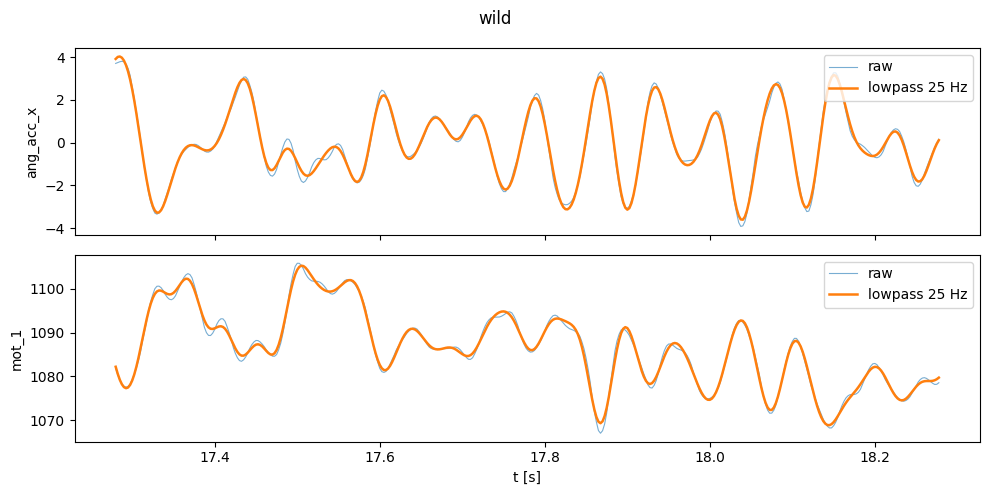

In [23]:
t = wild['t'].to_numpy(); win = (t >= t[0] + 2) & (t < t[0] + 3)
fig, ax = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
for a, ch in zip(ax, ['ang_acc_x', 'mot_1']):
    x = wild[ch].to_numpy()
    a.plot(t[win], x[win], lw=0.8, alpha=0.6, label='raw')
    a.plot(t[win], u.lowpass(x)[win], lw=1.8, label='lowpass 25 Hz')
    a.set_ylabel(ch); a.legend(loc='upper right')
ax[-1].set_xlabel('t [s]'); fig.suptitle('wild'); plt.tight_layout()

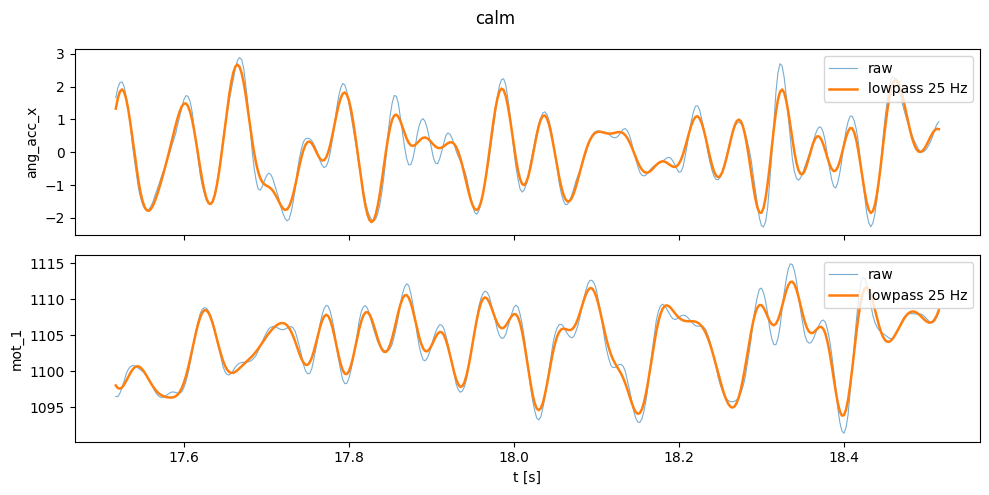

In [24]:
t = calm['t'].to_numpy(); win = (t >= t[0] + 2) & (t < t[0] + 3)
fig, ax = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
for a, ch in zip(ax, ['ang_acc_x', 'mot_1']):
    x = calm[ch].to_numpy()
    a.plot(t[win], x[win], lw=0.8, alpha=0.6, label='raw')
    a.plot(t[win], u.lowpass(x)[win], lw=1.8, label='lowpass 25 Hz')
    a.set_ylabel(ch); a.legend(loc='upper right')
ax[-1].set_xlabel('t [s]'); fig.suptitle('calm'); plt.tight_layout()

## SNR ranking (lower = noisier)

Position & quaternion dropped (absolute pose, not a noise question).

In [25]:
drop = ['pos_x', 'pos_y', 'pos_z', 'qx', 'qy', 'qz', 'qw']
snr_wild = u.snr_table(wild.drop(columns=drop))
snr_wild

,snr_db
ang_acc_z,15.404187
dmot_3,15.406128
dmot_1,15.976371
dmot_2,16.087042
dmot_4,16.323266
ang_vel_z,28.039190
ang_acc_x,28.140565
ang_acc_y,30.753711
mot_3,36.932002
mot_4,37.190865


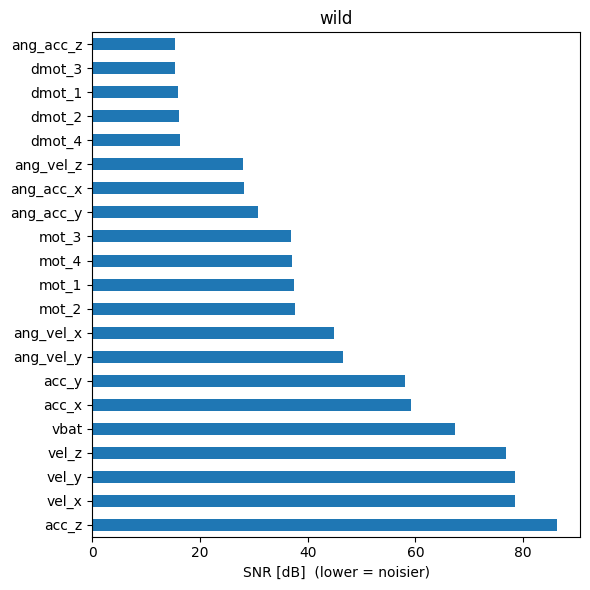

In [26]:
snr_wild['snr_db'].plot.barh(figsize=(6, 6)); plt.gca().invert_yaxis()
plt.xlabel('SNR [dB]  (lower = noisier)'); plt.title('wild'); plt.tight_layout()

In [27]:
snr_calm = u.snr_table(calm.drop(columns=drop))
snr_calm

,snr_db
dmot_4,6.780195
dmot_1,8.689175
dmot_3,8.950977
dmot_2,9.431164
ang_acc_z,11.243788
ang_vel_z,13.819350
ang_acc_x,15.266757
ang_acc_y,17.674260
ang_vel_y,25.517523
ang_vel_x,26.801356


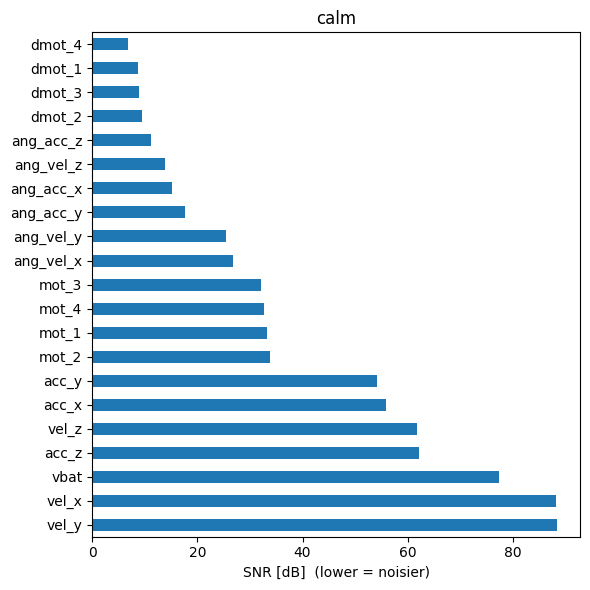

In [11]:
snr_calm['snr_db'].plot.barh(figsize=(6, 6)); plt.gca().invert_yaxis()
plt.xlabel('SNR [dB]  (lower = noisier)'); plt.title('calm'); plt.tight_layout()

## Cross-flight noise sweep

All 95 flights, segments concatenated per flight. Ranked by `snr_db` (dimensionless, so comparable across channels; lower = noisier). Pose columns dropped.

In [12]:
c = u.noise_corpus(cache='noise_corpus.csv')
c = c[~c.channel.str.startswith(('pos', 'q'))]
c.shape

(1995, 4)

### Q1 — which features are noisy (median across flights)

In [13]:
q1 = c.groupby('channel')['snr_db'].median().sort_values()
q1

channel
dmot_1        9.868695
dmot_4       10.037057
dmot_3       10.129159
dmot_2       10.304128
ang_acc_z    12.182937
ang_acc_x    18.941243
ang_acc_y    20.663870
ang_vel_z    30.948135
mot_3        40.338949
mot_4        40.580418
mot_1        41.119963
mot_2        41.197756
ang_vel_x    44.597835
ang_vel_y    44.648795
acc_x        59.917892
acc_y        60.851054
vbat         66.863051
vel_z        70.927893
vel_y        78.349499
vel_x        78.584768
acc_z        82.054424
Name: snr_db, dtype: float64

/var/folders/xw/ns2nqjw146sg3jt0ghqnyqpw0000gn/T/ipykernel_73360/268451189.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([c.snr_db[c.channel == ch] for ch in order], vert=False, labels=order)


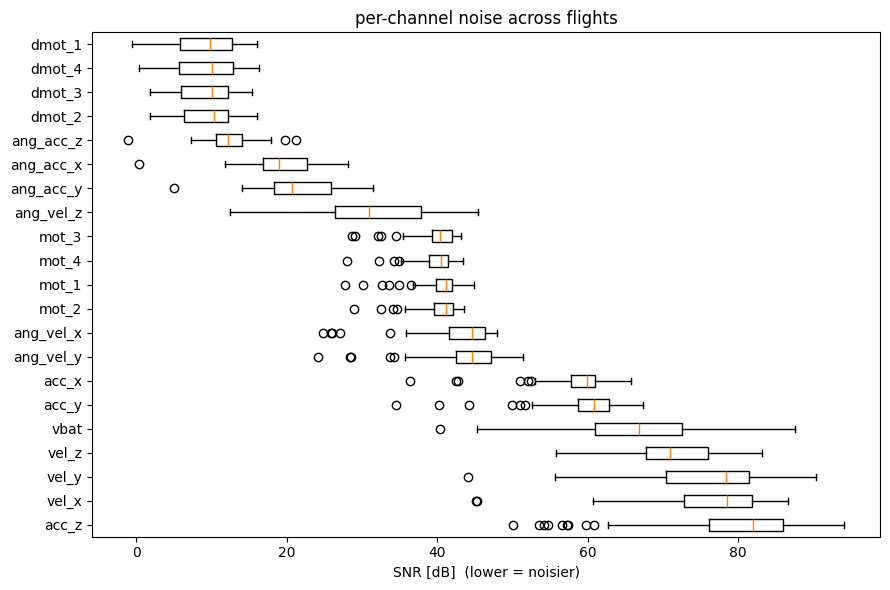

In [14]:
order = q1.index
plt.figure(figsize=(9, 6))
plt.boxplot([c.snr_db[c.channel == ch] for ch in order], vert=False, labels=order)
plt.gca().invert_yaxis(); plt.xlabel('SNR [dB]  (lower = noisier)')
plt.title('per-channel noise across flights'); plt.tight_layout()

### Q2 — noisiest flights (absolute noise of `ang_acc_x`)

SNR flags *calm* flights as noisy; rank by residual std of one channel instead (same units, so comparable flight-to-flight).

In [15]:
q2 = c[c.channel == 'ang_acc_x'].set_index('flight')['noise_std'].sort_values(ascending=False)
q2.head(10)

flight
2021-02-18-16-43-54    1.549550
2021-02-23-14-33-04    0.554223
2021-02-18-17-26-00    0.488047
2021-02-23-14-29-48    0.476933
2021-02-23-22-54-17    0.466600
2021-02-23-14-24-07    0.448047
2021-02-03-17-33-11    0.443883
2021-02-03-16-12-22    0.413608
2021-02-23-17-27-24    0.411675
2021-02-03-16-10-37    0.410098
Name: noise_std, dtype: float64

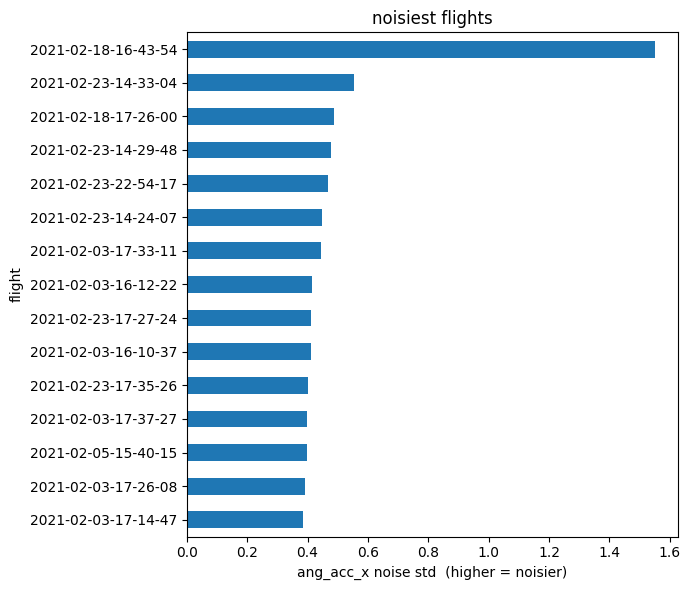

In [16]:
q2.head(15).plot.barh(figsize=(7, 6))
plt.gca().invert_yaxis(); plt.xlabel('ang_acc_x noise std  (higher = noisier)')
plt.title('noisiest flights'); plt.tight_layout()

### Flight × channel heatmap

Horizontal dark band = flight noisy everywhere; vertical dark band = channel noisy in every flight.

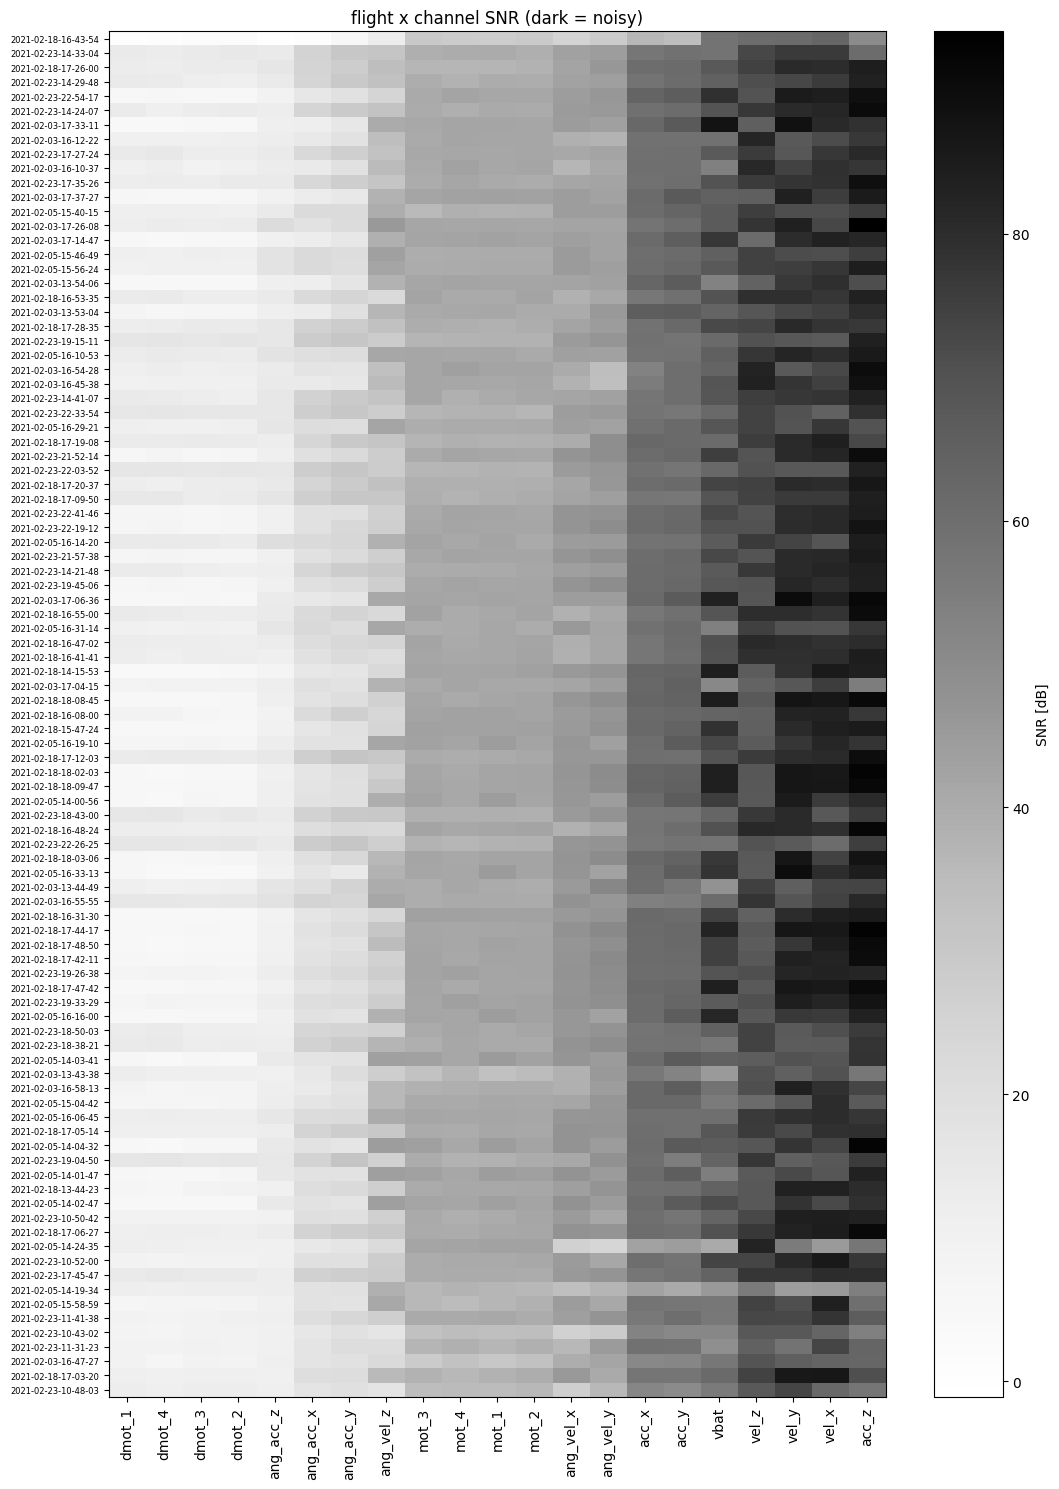

In [17]:
piv = c.pivot(index='flight', columns='channel', values='snr_db').loc[q2.index, order]
plt.figure(figsize=(11, 15))
plt.imshow(piv, aspect='auto', cmap='Grays')
plt.colorbar(label='SNR [dB]')
plt.xticks(range(len(order)), order, rotation=90)
plt.yticks(range(len(piv)), piv.index, fontsize=6)
plt.title('flight x channel SNR (dark = noisy)'); plt.tight_layout()